# Deep Learning with Python - 3th ed.
Francois Chollet
Matthew Watson


<img src="../pics/cover_DeepLearning.jpg" width=400> 

https://github.com/fchollet/deep-learning-with-python-notebooks

https://github.com/cr2003/BK_DeepLearning_with_Python_3ed



<a href="file:///C:/Users/crodr/OneDrive/InterChange/Books/Tech/DeepLearnig/Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf" target="_blank">Abrir PDF Local</a>

In [ ]:
import os

# Definimos la ruta de tu libro
ruta_libro = r"C:\Users\crodr\OneDrive\InterChange\Books\Tech\DeepLearnig\Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf"

# Esto le dice a Windows: "Abre este archivo con el programa por defecto del sistema"
os.startfile(ruta_libro)

In [1]:
!pwd

/c/Users/crodr/BK_tech/DeepLearning/BK_DeepLearning_with_Python_3ed/ch04


In [2]:
!python --version

Python 3.12.10


In [3]:
import os

os.environ["KERAS_BACKEND"] = "jax"

# Chapter 04 - Classification and regression
## 4.2 Classifying newswires: A multiclass classification example

In the previous section, you saw how to classify vector inputs into two mutually exclusive
classes using a densely connected neural network. But what happens when you
have more than two classes?

In this section, you’ll build a model to classify Reuters newswires into 46 mutually
exclusive topics. Because you have many classes, this problem is an instance of `multiclass classification`, 
and because each data point should be classified into only one category,
the problem is more specifically an instance of `single-label, multiclass classification`. If each
data point could belong to multiple categories (in this case, topics), you’d be facing a
`multilabel, multiclass classification` problem.


### 4.2.1 

You’ll work with the Reuters dataset, a set of short newswires and their topics, published
by Reuters in 1986. It’s a simple, widely used toy dataset for text classification.
There are 46 different topics; some topics are more represented than others, but each
topic has at least 10 examples in the training set.

Like IMDb and MNIST, the Reuters dataset comes packaged as part of Keras. Let’s
take a look.

In [10]:
# Listing 4.11 Loading the Reuters dataset

from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10_000
)

As with the IMDb dataset, the argument `num_words=10000` restricts the data to the
10,000 most frequently occurring words found in the data.

You have 8,982 training examples and 2,246 test examples:

In [11]:
len(train_data)

8982

In [12]:
len(test_data)

2246

As with the IMDb reviews, each example is a list of integers (word indices):

In [13]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

Here’s how you can decode it back to words, in case you’re curious.

In [14]:
# Listing 4.12 Decoding newswires back to text

word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# The indices are offset by 3 because, 0, 1, and 2, are reserved indices for
# "padding", "start of sequence", and "unknown"
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]
)

In [15]:
decoded_newswire

'? period ended december 31 shr profit 11 cts vs loss 24 cts net profit 224 271 vs loss 511 349 revs 7 258 688 vs 7 200 349 reuter 3'

The label associated with an example is an integer between 0 and 45—a topic index:

In [16]:
train_labels[10]

np.int64(3)

### Preparing the data
You can vectorize the data with the exact same code as in the previous example.

In [17]:
# Listing 4.13 Encoding the data
import numpy as np


def multi_hot_encode(sequences, num_classes):
    # creates an all-zero matrix of shape (len(sequences), num_classes)
    results = np.zeros((len(sequences), num_classes))

    for i, sequence in enumerate(sequences):
        # sets specific indices of results[i] to 1s
        results[i][sequence] = 1.0
    return results


x_train = multi_hot_encode(train_data, num_classes=10_000)  # Vectorized training data
x_test = multi_hot_encode(test_data, num_classes=10_000)  # Vectorized test data


To vectorize the labels, there are two possibilities: you can leave the labels untouched
as integers, or you can use one-hot encoding. One-hot encoding is a widely used format
for categorical data, also called categorical encoding. In this case, one-hot encoding of
the labels consists of embedding each label as an all-zero vector with a 1 in the place of
the label index. Here’s an example.

In [18]:
# Listing 4.14 Encoding the labels


def one_hot_encode(labels, num_classes=46):
    results = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results


y_train = one_hot_encode(train_labels)  # Vectorized training labels
y_test = one_hot_encode(test_labels)  # Vectorized test labels


Note that there is a built-in way to do this in Keras:

In [19]:
from keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)


### 4.2.3 Building your model

This topic classification problem looks similar to the previous movie review classification
problem: in both cases, you’re trying to classify short snippets of text. But there is
a new constraint here: the number of output classes has gone from 2 to 46. The dimensionality
of the output space is much larger.

In a stack of `Dense` layers like those you’ve been using, each layer can only access
information present in the output of the previous layer. If one layer drops some
information relevant to the classification problem, this information can never be
recovered by later layers: each layer can potentially become an information bottleneck.
In the previous example, you used 16-dimensional intermediate layers, but a
16-dimensional space may be too limited to learn to separate 46 different classes:
such small layers may act as information bottlenecks, permanently dropping relevant
information.

For this reason, you’ll use larger intermediate layers. Let’s go with 64 units.

In [20]:
# Listing 4.15 Model definition
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

There are two other things you should note about this architecture:

* You end the model with a `Dense` layer of size 46. This means for each input sample,
the network will output a 46-dimensional vector. Each entry in this vector
(each dimension) will encode a different output class.

* The last layer uses a `softmax` activation. You saw this pattern in the MNIST example.
It means the model will output a probability distribution over the 46 different
output classes—for every input sample, the model will produce a 46-dimensional
output vector, where output[i] is the probability that the sample belongs to class
i. The 46 scores will sum to 1.

The best loss function to use in this case is `categorical_crossentropy`. It measures the
distance between two probability distributions—here, between the probability distribution
outputted by the model and the true distribution of the labels. By minimizing
the distance between these two distributions, you train the model to output something
as close as possible to the true labels.

Like last time, we’ll also monitor `accuracy`. However, accuracy is a bit of a crude
metric in this case: if the model has the correct class as its second choice for a given
sample, with an incorrect first choice, the model will still have an accuracy of zero on
that sample—even though such a model would be much better than a random guess.
A more nuanced metric in this case is top-k accuracy, such as top-3 or top-5 accuracy. It
measures whether the correct class was among the top-k predictions of the model. Let’s
add top-3 accuracy to our model.

In [21]:
# Listing 4.16 Compiling model

top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(k=3, name="top_3_accuracy")

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy],
)

### 4.2.4 Validating your approach

Let’s set apart 1,000 samples in the training data to use as a validation set.

In [22]:
# Listing 4.17 Setting aside a validation set

x_val = x_train[:1_000]
partial_x_train = x_train[1000:]
y_val = y_train[:1_000]
partial_y_train = y_train[1000:]

Now, let’s train the model for 20 epochs.

In [23]:
# Listing 4.18 Training the model

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.4250 - loss: 3.3427 - top_3_accuracy: 0.5417 - val_accuracy: 0.5520 - val_loss: 2.5598 - val_top_3_accuracy: 0.6490
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6089 - loss: 1.9901 - top_3_accuracy: 0.7212 - val_accuracy: 0.6590 - val_loss: 1.6378 - val_top_3_accuracy: 0.7580
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7155 - loss: 1.3479 - top_3_accuracy: 0.8032 - val_accuracy: 0.7150 - val_loss: 1.2991 - val_top_3_accuracy: 0.8100
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7820 - loss: 1.0272 - top_3_accuracy: 0.8648 - val_accuracy: 0.7580 - val_loss: 1.1522 - val_top_3_accuracy: 0.8550
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8329 - loss: 0.8035 - top_3_accuracy: 0.9072 - val_accuracy: 0.7840 - val_loss: 1.0438 - val_top_3_accuracy: 0.8780
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8692 - loss: 0.6269 - top_3_ac

And finally, let’s display its loss and accuracy curves (see figures 4.6 and 4.7).

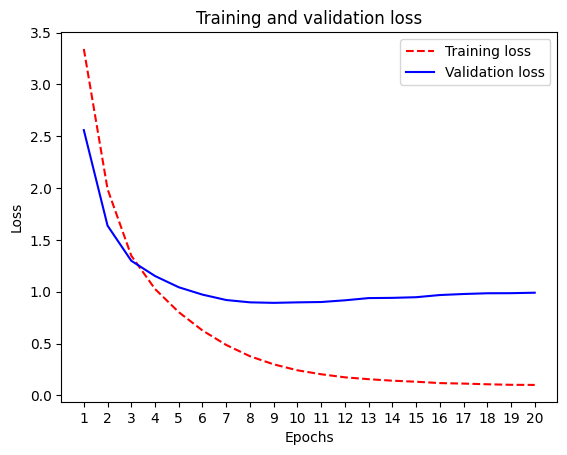

In [24]:
# Listing 4.19 Plotting the training and validation loss

import matplotlib.pyplot as plt

loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()


**Figure 4.6 Training and validation loss**

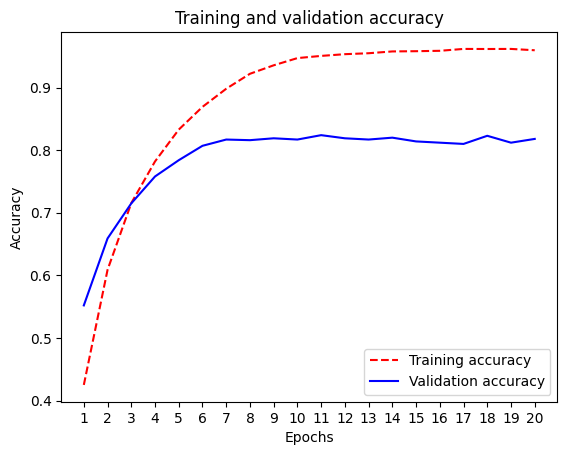

In [25]:
# Listing 4.20 Plotting the training and validation accuracy

plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()


**Figure 4.7 Training and validation accuracy**

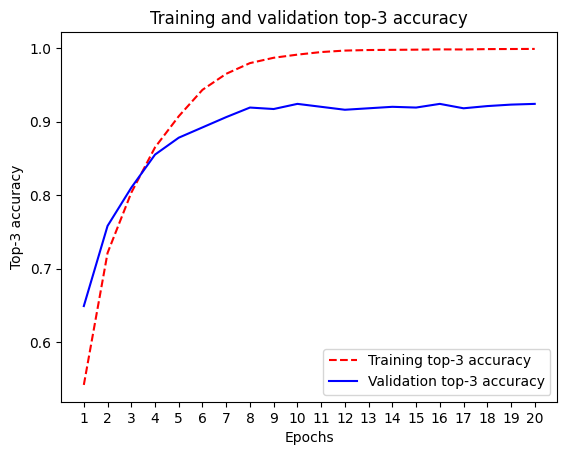

In [26]:
# Listing 4.21 Plotting the training and validation top-3 accuracy

plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()


**Figure 4.7 Training and validation accuracy**

The model begins to overfit after nine epochs. Let’s train a new model from scratch for
nine epochs and then evaluate it on the test set.

In [27]:
# Listing 4.22 Retraining a model from scratch

model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)

results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.4741 - loss: 3.2966
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6465 - loss: 1.9323
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7311 - loss: 1.2787
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7875 - loss: 0.9786
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8352 - loss: 0.7677
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8726 - loss: 0.6018
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8980 - loss: 0.4696
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9230 - loss: 0.3693
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9381 - loss: 0.2960
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7912 - loss: 0.9436


Here are the final results:

In [28]:
results

[0.9436242580413818, 0.7911843061447144]

This approach reaches an accuracy of approximately 80%. With a balanced binary classification
problem, the accuracy reached by a purely random classifier would be 50%.
But in this case, we have 46 classes, and they may not be equally represented. What
would be the accuracy of a random baseline? We could try quickly implementing one
to check this empirically:

In [29]:
import copy

test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels == test_labels_copy)
hits_array.mean()

np.float64(0.18477292965271594)

As you can see, a random classifier would score around 19% classification accuracy, so
the results of our model seem pretty good in that light.

### 4.2.5 Generating predictions on new data

Calling the model’s `predict` method on new samples returns a class probability distribution
over all 46 topics for each sample. Let’s generate topic predictions for all of the
test data:

In [30]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Each entry in “predictions” is a vector of length 46:

In [31]:
predictions[0]

array([9.84106737e-05, 1.18921103e-04, 2.39298988e-05, 6.79750621e-01,
       3.01046818e-01, 1.10046363e-04, 1.05577183e-03, 1.50075954e-04,
       2.70276656e-03, 5.98921150e-04, 1.12553156e-04, 1.16294390e-03,
       1.10447574e-04, 5.18230605e-04, 1.46351986e-05, 5.41607515e-05,
       4.09053406e-03, 3.61021899e-04, 1.27477542e-04, 9.42392449e-04,
       8.80088832e-04, 3.80126759e-04, 8.70900840e-06, 3.37031990e-04,
       1.32093237e-05, 2.71823752e-04, 1.88954782e-05, 2.16803179e-04,
       6.31963310e-04, 1.34591584e-03, 2.57359381e-04, 8.30409772e-05,
       1.54967813e-04, 1.37530078e-05, 1.42063989e-04, 2.87753137e-05,
       2.75442115e-04, 3.20704603e-05, 3.45990033e-04, 5.49068092e-04,
       1.04010151e-05, 2.98617844e-04, 2.47542812e-05, 9.64520295e-05,
       1.48505285e-06, 4.30583983e-04], dtype=float32)

In [32]:
predictions[0].shape


(46,)

The coefficients in this vector sum to 1, as they form a probability distribution:

In [33]:
np.sum(predictions[0])

np.float32(1.0000001)

The largest entry is the predicted class—the class with the highest probability:

In [34]:
np.argmax(predictions[0])

np.int64(3)

### 4.2.6 A different way to handle the labels and the loss

We mentioned earlier that another way to encode the labels would be to leave them
untouched as integer tensors, like this:

In [35]:
y_train = train_labels
y_test = test_labels

The only thing this approach would change is the choice of the loss function.
The loss function used in listing 4.22, `categorical_crossentropy`, expects the
labels to follow a categorical encoding. With integer labels, you should use
`sparse_categorical_crossentropy`:

In [ ]:
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

This new loss function is still mathematically the same as `categorical_crossentropy`; it
just has a different interface.

### 4.2.7 The importance of having sufficiently large intermediate layers

We mentioned earlier that because the final outputs are 46-dimensional, you should
avoid intermediate layers with much fewer than 46 units. Now let’s see what happens
when you introduce an information bottleneck by having intermediate layers that are
significantly less than 46-dimensional: for example, 4-dimensional.

In [ ]:
# Listing 4.23 A model with an Information bottleneck

model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.1808 - loss: 3.3235 - val_accuracy: 0.2520 - val_loss: 2.5930
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5019 - loss: 2.0052 - val_accuracy: 0.6000 - val_loss: 1.6645
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6476 - loss: 1.4163 - val_accuracy: 0.6610 - val_loss: 1.4948
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7105 - loss: 1.2108 - val_accuracy: 0.6790 - val_loss: 1.4564
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7219 - loss: 1.1048 - val_accuracy: 0.6760 - val_loss: 1.4460
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7285 - loss: 1.0288 - val_accuracy: 0.6760 - val_loss: 1.4604
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7323 - loss: 0.9699 - val_accuracy: 0.6770 - val_loss: 1.4852
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7382 - loss: 0.9198 - val_accuracy: 0.6720 - val_loss

The model now peaks at approximately 67% validation accuracy, an 10% absolute
drop. This drop is mostly due to the fact that you’re trying to compress a lot of information
(enough information to recover the separation hyperplanes of 46 classes)
into an intermediate space that is too low-dimensional. The model is able to cram
most of the necessary information into these 4-dimensional representations, but not
all of it.